In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
import re

In [126]:
file_path = "./sentiment_Aspect_added.xlsx"
data = pd.read_excel(file_path)
data.head(

)

,Comment ID,Comment,Business Sentiment,Content Sentiment
0,1,"මේ නිෂ්පාදනය නම් ලස්සනයි, නමුත් පාවිච්චිය ටිකක...",Negative,Positive
1,1,rashmika වගේ,Neutral,Positive
2,1,rashmika වෙගේ අඩේ,Neutral,Neutral
3,1,සාරංග,Neutral,Neutral
4,1,ඉස්සරහට නිලියක් ශුවර්,Neutral,Neutral


In [127]:
# Finding unique values in each column
unique_business_sentiment = data['Business Sentiment'].unique()
# Print unique values
print("Unique values in Business Sentiment:", unique_business_sentiment)

Unique values in Business Sentiment: ['Negative' 'Neutral' 'Positive' nan '...' 'neg']


In [128]:
unique_content_sentiment = data['Content Sentiment'].unique()
print("Unique values in Content Sentiment:", unique_content_sentiment)

Unique values in Content Sentiment: ['Positive' 'Neutral' 'Negative' nan 'Negative ' '...']


In [129]:
# Define replacements
replacement_dict2 = {
    'positive': 'Positive',
    'negative': 'Negative',
    'Negative ':'Negative',
    'Netural': 'Neutral',
    'nan': None,  # Replace 'nan' with None
   '...':None
}

# Replace values in 'Business Sentiment' column
data['Content Sentiment'].replace(replacement_dict2, inplace=True)

# Filter out rows with None (to remove 'nan' and '...')
data = data[data['Content Sentiment'].notna()]

# Check unique values after replacement and filtering
unique_content_sentiment = data['Content Sentiment'].unique()

print("Unique values in Content Sentiment after replacement and filtering:")
print(unique_content_sentiment)

Unique values in Content Sentiment after replacement and filtering:
['Positive' 'Neutral' 'Negative']


In [130]:
# Define replacements
replacement_dict = {
    'positive': 'Positive',
    'eneg': 'Negative',
    'neg': 'Negative',
    'nan': None,  # Replace 'nan' with None
    '...': None    # Replace '...' with None
}

# Replace values in 'Business Sentiment' column
data['Business Sentiment'].replace(replacement_dict, inplace=True)

# Filter out rows with None (to remove 'nan' and '...')
data = data[data['Business Sentiment'].notna()]

# Check unique values after replacement and filtering
unique_business_sentiment = data['Business Sentiment'].unique()

print("Unique values in Business Sentiment after replacement and filtering:")
print(unique_business_sentiment)

Unique values in Business Sentiment after replacement and filtering:
['Negative' 'Neutral' 'Positive']


In [131]:
# Finding unique values in each column
unique_business_sentiment = data['Business Sentiment'].unique()
unique_content_sentiment = data['Content Sentiment'].unique()

# Print unique values
print("Unique values in Business Sentiment:", unique_business_sentiment)
print("Unique values in Content Sentiment:", unique_content_sentiment)

Unique values in Business Sentiment: ['Negative' 'Neutral' 'Positive']
Unique values in Content Sentiment: ['Positive' 'Neutral' 'Negative']


In [132]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [133]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform 'Business Sentiment' and 'Content Sentiment' columns
data['Business Sentiment'] = label_encoder.fit_transform(data['Business Sentiment'])
data['Content Sentiment'] = label_encoder.fit_transform(data['Content Sentiment'])

In [134]:
data.head()

,Comment ID,Comment,Business Sentiment,Content Sentiment
0,1,"මේ නිෂ්පාදනය නම් ලස්සනයි, නමුත් පාවිච්චිය ටිකක...",0,2
1,1,rashmika වගේ,1,2
2,1,rashmika වෙගේ අඩේ,1,1
3,1,සාරංග,1,1
4,1,ඉස්සරහට නිලියක් ශුවර්,1,1


In [135]:
# Find unique values in 'Business Sentiment' and 'Content Sentiment' columns
unique_business_sentiments = data['Business Sentiment'].unique()
unique_content_sentiments = data['Content Sentiment'].unique()

# Print the unique values
print("Unique Business Sentiments:", unique_business_sentiments)
print("Unique Content Sentiments:", unique_content_sentiments)

Unique Business Sentiments: [0 1 2]
Unique Content Sentiments: [2 1 0]


In [136]:
data.shape

(10927, 4)

In [137]:
data.duplicated().sum()

1867

In [138]:
data.isnull().sum()

Comment ID            0
Comment               1
Business Sentiment    0
Content Sentiment     0
dtype: int64

In [139]:
data.head(10)

,Comment ID,Comment,Business Sentiment,Content Sentiment
0,1,"මේ නිෂ්පාදනය නම් ලස්සනයි, නමුත් පාවිච්චිය ටිකක...",0,2
1,1,rashmika වගේ,1,2
2,1,rashmika වෙගේ අඩේ,1,1
3,1,සාරංග,1,1
4,1,ඉස්සරහට නිලියක් ශුවර්,1,1
5,1,rashmika මතක් උනා. එයා වගේ ටිකක්,1,1
6,1,ව්‍යාකූල උනා පිපිරීම මීට සාරන්ග,0,1
7,1,මේ අර සිකුරු ඇවිත් ට්‍රාමා එකේ අන්ජලී නේද?,1,1
8,1,එයා නම් ලස්සනයි,1,2
9,1,She is ලස්සන,2,2


In [140]:
def remove_links(text):
    if isinstance(text, str):
        # Remove URLs starting with http or https
        text = re.sub(r'http\S+', '', text)
        # Remove URLs starting with www
        text = re.sub(r'www\S+', '', text)
        return text

# Apply the function to the 'Comment' column
data['Comment'] = data['Comment'].apply(remove_links).astype(str)



def remove_punctuation(text):
    if isinstance(text, str):
        # Remove punctuation marks
        text = text.translate(str.maketrans('', '', string.punctuation))
    return text

# Apply the function to the 'Comment' column
data['Comment'] = data['Comment'].apply(remove_punctuation)

data["Comment"] = data['Comment'].str.replace('\d+', '', regex=True)

In [141]:
data.head()

,Comment ID,Comment,Business Sentiment,Content Sentiment
0,1,මේ නිෂ්පාදනය නම් ලස්සනයි නමුත් පාවිච්චිය ටිකක්...,0,2
1,1,rashmika වගේ,1,2
2,1,rashmika වෙගේ අඩේ,1,1
3,1,සාරංග,1,1
4,1,ඉස්සරහට නිලියක් ශුවර්,1,1


In [142]:
# Function to check if a comment contains only Sinhala text
def is_sinhala_text(comment):
    # Regular expression to match only Sinhala characters and spaces
    sinhala_pattern = re.compile(r'^[\u0D80-\u0DFF\s]+$')
    return bool(sinhala_pattern.match(comment))

data['Comment'] = data['Comment'].astype(str)
# Filter rows with only Sinhala text and remove the 'Comment ID' column
filtered_data = data[data['Comment'].apply(is_sinhala_text)].drop(columns=['Comment ID'])

In [143]:
filtered_data.head(5)

,Comment,Business Sentiment,Content Sentiment
0,මේ නිෂ්පාදනය නම් ලස්සනයි නමුත් පාවිච්චිය ටිකක්...,0,2
3,සාරංග,1,1
4,ඉස්සරහට නිලියක් ශුවර්,1,1
8,එයා නම් ලස්සනයි,1,2
10,සේවාව මට අකමැති නමුත් කණ්ඩායම හොඳයි,0,2


In [144]:
from collections import Counter
vocab = Counter()

In [145]:
for sentence in filtered_data['Comment']:
    vocab.update(sentence.split())

In [146]:
# vocab

In [147]:

len(vocab)

6175

In [148]:
tokens = [key for key in vocab if vocab[key] > 5]

In [149]:
# tokens

In [150]:
len(tokens)

760

In [151]:
def save_vocabulary(lines, filename):
    data = '\n'.join(lines)
    file = open(filename, 'w', encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, './vocabulary.txt')

In [152]:
X = filtered_data['Comment']
y = filtered_data['Content Sentiment']

In [153]:
X

0        මේ නිෂ්පාදනය නම් ලස්සනයි නමුත් පාවිච්චිය ටිකක්...
3                                                    සාරංග
4                                    ඉස්සරහට නිලියක් ශුවර්
8                                          එයා නම් ලස්සනයි
10                     සේවාව මට අකමැති නමුත් කණ්ඩායම හොඳයි
                               ...                        
10925                           තෙරුවන් සරණයි නියමයි අගෙයි
10926                                          ගෞරවය අයියේ
10927                                                පිනක්
10928                                        තෙරුවන් සරණයි
10929                                         සුපිරි මල්ලි
Name: Comment, Length: 5745, dtype: object

In [154]:
y

0        2
3        1
4        1
8        2
10       2
        ..
10925    2
10926    2
10927    2
10928    2
10929    2
Name: Content Sentiment, Length: 5745, dtype: int64

In [156]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [157]:
X_train.shape

(4596,)

In [158]:
X_test.shape

(1149,)

In [159]:
def vectorizer(ds, vocabulary):
    vectorized_lst = []

    for sentence in ds:
        sentence_lst = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_lst[i] = 1

        vectorized_lst.append(sentence_lst)

    vectorized_lst_new = np.asarray(vectorized_lst, dtype=np.float32)

    return vectorized_lst_new

In [160]:
vectorized_x_train = vectorizer(X_train, tokens)

In [161]:
vectorized_x_train

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [162]:
vectorized_x_test = vectorizer(X_test, tokens)

In [164]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [163]:
y_train.value_counts()

Content Sentiment
2    2491
1    1563
0     542
Name: count, dtype: int64

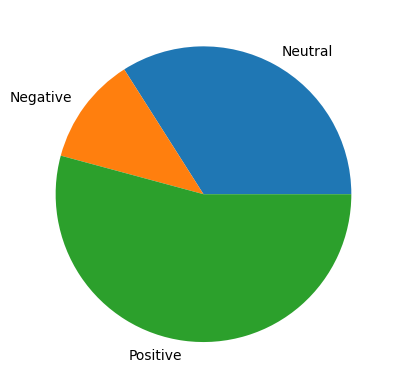

In [165]:
plt.pie(np.array([y_train.value_counts()[1], y_train.value_counts()[0], y_train.value_counts()[2]]), labels=['Neutral', 'Negative', 'Positive'])
plt.show()

In [166]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)

(7473, 760) (7473,)


In [167]:
y_train_smote.value_counts()

Content Sentiment
1    2491
0    2491
2    2491
Name: count, dtype: int64

In [236]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [170]:
# Define the neural network
model = Sequential()

In [206]:
# Define the neural network with more complexity and regularization
model = Sequential()
model.add(Dense(256, input_shape=(760,), activation='relu'))
# model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [204]:
# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [209]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

In [289]:
# Define the neural network with more complexity and regularization
model = Sequential()
model.add(Dense(256, input_shape=(760,), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Compile the model with an adjusted learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Print the model summary
model.summary()

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

# Train the model with additional callbacks
history = model.fit(
    vectorized_x_train_smote, y_train_smote,
    epochs=20,
    validation_data=(vectorized_x_test, y_test),
    batch_size=16,
    callbacks=[early_stopping, reduce_lr]
)



Model: "sequential_44"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_225 (Dense)           (None, 256)               194816    
                                                                 
 dropout_123 (Dropout)       (None, 256)               0         
                                                                 
 dense_226 (Dense)           (None, 128)               32896     
                                                                 
 dropout_124 (Dropout)       (None, 128)               0         
                                                                 
 dense_227 (Dense)           (None, 64)                8256      
                                                                 
 dropout_125 (Dropout)       (None, 64)                0         
                                                                 
 dense_228 (Dense)           (None, 32)              

36/36 [==============================] - 0s 2ms/step
Precision: 0.6809960851048638
Recall: 0.6266318537859008
F1 Score: 0.6465056532550344
Confusion Matrix:
[[ 58  45  13]
 [ 95 207  80]
 [ 76 120 455]]


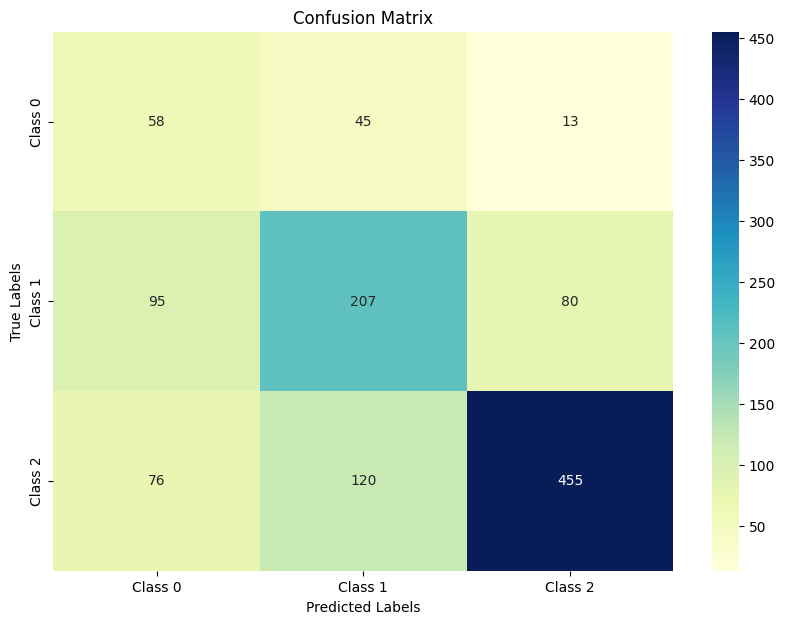

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.25      0.50      0.34       116
     Class 1       0.56      0.54      0.55       382
     Class 2       0.83      0.70      0.76       651

    accuracy                           0.63      1149
   macro avg       0.55      0.58      0.55      1149
weighted avg       0.68      0.63      0.65      1149



In [290]:
# Predict the labels for the test set
y_pred_probs = model.predict(vectorized_x_test)
y_pred = np.argmax(y_pred_probs, axis=-1)

# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision}')

recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall}')

f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{cm}')

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2'])
print(f'Classification Report:\n{report}')

In [316]:
import numpy as np

# Assuming you have a new list of Sinhala comments
new_comments = [
    "මේ නිෂ්පාදනය නම් ලස්සනයි නමුත් පාවිච්චිය ටිකක්...",
    "සාරංග",
    "ඉස්සරහට නිලියක් ශුවර්",
    "අනවශ්‍ය",
    "සේවාව මට අකමැති නමුත් කණ්ඩායම හොඳයි",
    "බොරු",
    "ඹෝරු කියන්න එපා",
    "ඒක ලස්සන නැ"
    # Add more comments as needed
]

# Vectorize the new comments using the same vocabulary
def vectorize_new_comments(comments, vocabulary):
    vectorized_lst = []

    for sentence in comments:
        sentence_lst = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_lst[i] = 1

        vectorized_lst.append(sentence_lst)

    vectorized_lst_new = np.asarray(vectorized_lst, dtype=np.float32)

    return vectorized_lst_new

vectorized_new_comments = vectorize_new_comments(new_comments, tokens)

# Predict the labels for the new comments
predictions = model.predict(vectorized_new_comments)
predicted_labels = np.argmax(predictions, axis=-1)

# Map the predicted labels back to their corresponding sentiment values
label_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}
predicted_sentiments = [label_mapping[label] for label in predicted_labels]

# Print the comments with their predicted sentiments
for comment, sentiment in zip(new_comments, predicted_sentiments):
    print(f"Comment: {comment}\nPredicted Sentiment: {sentiment}\n")

# Calculate the percentage of each sentiment
unique, counts = np.unique(predicted_labels, return_counts=True)
sentiment_distribution = dict(zip(unique, counts))
total_comments = len(new_comments)

print("Content Sentiment Analysis:")
print("---------------------------")

# Print the percentage of each sentiment
for sentiment, count in sentiment_distribution.items():
    percentage = (count / total_comments) * 100
    print(f"{label_mapping[sentiment]}: {percentage:.2f}%")


1/1 [==============================] - 0s 29ms/step
Comment: මේ නිෂ්පාදනය නම් ලස්සනයි නමුත් පාවිච්චිය ටිකක්...
Predicted Sentiment: Positive

Comment: සාරංග
Predicted Sentiment: Neutral

Comment: ඉස්සරහට නිලියක් ශුවර්
Predicted Sentiment: Neutral

Comment: අනවශ්‍ය
Predicted Sentiment: Negative

Comment: සේවාව මට අකමැති නමුත් කණ්ඩායම හොඳයි
Predicted Sentiment: Positive

Comment: බොරු
Predicted Sentiment: Negative

Comment: ඹෝරු කියන්න එපා
Predicted Sentiment: Negative

Comment: ඒක ලස්සන නැ
Predicted Sentiment: Positive

Content Sentiment Analysis:
---------------------------
Negative: 37.50%
Neutral: 25.00%
Positive: 37.50%


batch size 16 and add three dense layers . still accuracy 71% recall for class 0.go further with this approach

In [ ]:
model.save('./my_model.h5')